In [25]:
import sys
print(sys.executable)


D:\Anaconda\python.exe


# 🧠 Food Waste Forecasting AI Project

A machine learning-powered project to **analyze, predict, and reduce food waste** in school canteens — aligned with:

- 🌱 **SDG 2: Zero Hunger**  
- ♻️ **SDG 12: Responsible Consumption and Production**

---

### 💻 Tech Stack:
Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn, Tkinter

---

### 🔁 Project Workflow (3 Phases):

- 🔍 **Phase 0 – Data Analytics:**  
  Understand the dataset with summaries, trends, and correlation insights.

- 📐 **Phase 1 – Rule-based Recommendation:**  
  Recommend ideal food preparation using past sold and waste data (no ML).

- 🤖 **Phase 2 – ML-based Prediction:**  
  Predict quantity sold using Linear Regression based on prepared food and past trends.

---

### 📂 Outputs:
- Final recommended quantities (CSV)  
- Visuals saved to `plots/`  
- Trained model saved as `sold_prediction_model.pkl`  

---

### 🙌 Team Credits:
- Itikaa Rana
- Saksham Piyush Patil 
- Aahana Gautam
- Tanisha Chaudhary 
- Anant Sharma

#### “Predict smart. Waste less. Feed more.” 🍽️


## 📊 Phase 0: Exploratory Data Analysis (EDA)

Before diving into prediction and recommendation, this phase focuses on understanding the dataset and extracting useful insights. It helps identify patterns, trends, anomalies, and correlations that guide the later modeling phases.

### 🔍 Objectives of this Phase:
- Understand the overall structure and health of the dataset.
- Identify which food items are frequently wasted.
- Observe day-wise trends in food preparation, sale, and wastage.
- Discover relationships between features (like how strongly "prepared" and "sold" quantities are correlated).

### ✅ Key Analyses Performed:

**Preprocessing**:
   - Missing values handled
   - Invalid or unknown food items dropped
   - Dates converted to proper datetime format
   - Day of the week extracted and encoded
   - Negative or non-sensible values removed

**Descriptive Statistics:** Mean, median, min-max for quantity columns.
**Item-wise Waste Analysis:** Identify which food items are causing more waste.
**Day-wise Waste Trends:** Spot patterns across weekdays.
**Correlation Heatmap:** Visualize how different numerical features relate to each other.
  > Helps in feature selection for future model building and understanding which variables impact waste the most.

---


This phase acts as the **foundation** of the project by ensuring we're not flying blind when building models. A good model always starts with a good understanding of the data.



✅ Combined CSVs loaded. Total rows: 654
📋 Your file contains these columns:
['Date', 'Item Name', 'Quantity_Prepared', 'Quantity_Sold', 'Quantity_Wasted']

✅ File loaded with correct format!
📊 Initial Data Overview
Shape: (654, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 654 entries, 0 to 653
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               654 non-null    object 
 1   Item Name          654 non-null    object 
 2   Quantity_Prepared  654 non-null    int64  
 3   Quantity_Sold      626 non-null    float64
 4   Quantity_Wasted    654 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 25.7+ KB
None
         Date Item Name  Quantity_Prepared  Quantity_Sold  Quantity_Wasted
0  2025-01-01    samosa                 22           20.0                1
1  2025-01-01  sandwich                 20           20.0                0
2  2025-01-01    burger            

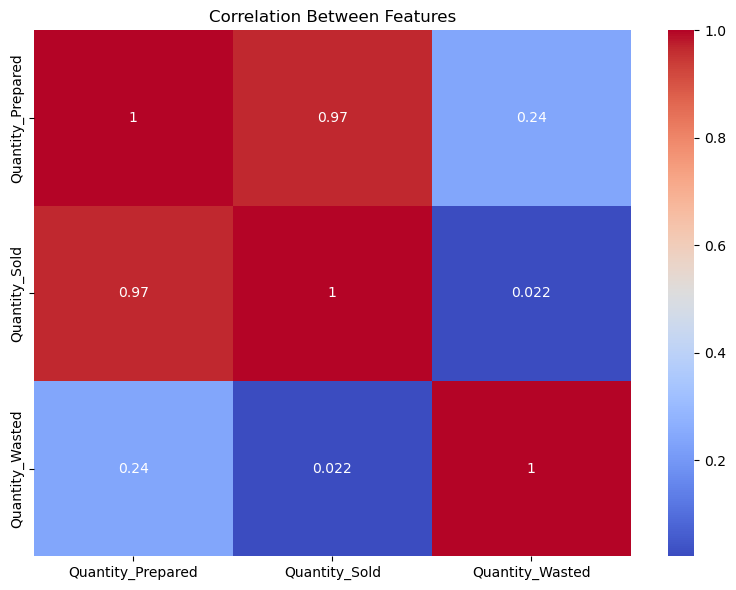


📌 Plot saved? True
✅ Item-wise waste summary saved.
✅ Day-wise average quantities saved.


In [41]:
# PHASE - 0 
# 📂 Step 1: Upload Excel or CSV file

import pandas as pd
import os
import glob
import sys
import seaborn as sns
import matplotlib.pyplot as plt
from rapidfuzz import process

# Adjust this path to your folder location
files = glob.glob(r"D:\Downloads\AI Project\Datasets\canteen_data_noisy_*.csv")

# Combine all files
combined_data = []
for f in files:
    df = pd.read_csv(f)
    if "Item Name" in df.columns:
        df.columns = df.columns.str.strip()
        # Drop any duplicate 'Item' column
        df = df.drop(columns=[col for col in df.columns if col.strip().lower() == "item"], errors='ignore')
        combined_data.append(df)
    else:
        print(f"⚠️ Skipped (no 'Item Name' column): {os.path.basename(f)}")

# Check if we got any valid files
if not combined_data:
    raise ValueError("❌ No valid files with 'Item Name' column found.")

# Concatenate all data
df_p0 = pd.concat(combined_data, ignore_index=True)
print("\n✅ Combined CSVs loaded. Total rows:", len(df_p0))
print("📋 Your file contains these columns:")
print(df_p0.columns.tolist())

# 🔍 Column sanity check
expected_cols = {'Date', 'Item Name', 'Quantity_Prepared', 'Quantity_Sold', 'Quantity_Wasted'}
if not expected_cols.issubset(df_p0.columns):
    raise ValueError("❌ Dataset missing required columns. Please check format.")
print("\n✅ File loaded with correct format!")

# ✅ Preprocessing the dataset
sys.path.append(r"D:\Downloads\AI Project\Trained model and Notebook")
from data_clean import preprocess

df = preprocess(df_p0)  # Fix: was mistakenly written as preprocess(df)
print("✅ Rows after preprocessing:", len(df))

assert not df.isnull().values.any(), "❌ Missing values found in data after preprocessing!"

# Save cleaned data for future use
df.to_csv(r"D:\Downloads\AI Project\Datasets\cleaned_data.csv", index=False)
print("💾 Cleaned data saved as 'cleaned_data.csv'")

# Data Summary
print("\n Missing Values:")
print(df_p0.isnull().sum())

print("\n Descriptive Stats:")
print(df_p0.describe())

print("\n Data Types:")
print(df_p0.dtypes)

# Waste Summary
if 'Quantity_Wasted' in df_p0.columns and 'Item Name' in df_p0.columns:
    item_waste = df_p0.groupby('Item Name')['Quantity_Wasted'].mean().sort_values(ascending=False)
    print("🍔 Average Waste per Item:")
    print(item_waste)
else:
    print("⚠️ Required columns missing for waste summary.")

# Day-wise Summary
df_p0['Date'] = pd.to_datetime(df_p0['Date'], errors='coerce')
df_p0['Day_of_Week'] = df_p0['Date'].dt.day_name()
day_summary = df_p0.groupby('Day_of_Week')[['Quantity_Prepared', 'Quantity_Sold', 'Quantity_Wasted']].mean()
day_summary = day_summary.reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'])
print("\n🗕 Average Quantities per Day:")
print(day_summary)

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df_p0[['Quantity_Prepared', 'Quantity_Sold', 'Quantity_Wasted']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Features")
plt.tight_layout()

# Save plot
output_dir = r"D:\Downloads\AI Project\Plots and Visualisations"
os.makedirs(output_dir, exist_ok=True)
plt.savefig(os.path.join(output_dir, "correlation_heatmap.png"))
plt.show()
print("\n📌 Plot saved?", os.path.exists(os.path.join(output_dir, "correlation_heatmap.png")))

# Final Outputs
output_dir = r"D:\Downloads\AI Project\Final Outputs"
os.makedirs(output_dir, exist_ok=True)

item_waste_rounded = item_waste.fillna(0).round(0).astype(int)
item_waste_rounded.to_csv(os.path.join(output_dir, "Final_Output_Itemwise_Waste_p0.csv"))
print("✅ Item-wise waste summary saved.")

day_summary_rounded = day_summary.round(0).astype(int)
day_summary_rounded.to_csv(os.path.join(output_dir, "Final_Output_Daywise_Averages_p0.csv"))
print("✅ Day-wise average quantities saved.")


### 🔷 Phase 1: Smart Recommendation using Past Data

In this phase, we calculate the **ideal quantity to prepare** for each food item based on **past sales and wastage trends**. No AI model is used here — just smart data analysis and logic.

#### 📌 Key Steps:
1. **Input**: Historical canteen dataset with these columns:
   - `Date`, `Item Name`, `Quantity_Prepared`, `Quantity_Sold`, `Quantity_Wasted`

4. **Recommendation Logic**:
   - Waste is subtracted from average sales (plus buffer) to recommend an ideal quantity
   - Formula used:
     ```
     df['Recommended_Qty'] = (df['Quantity_Sold'] + buffer).clip(lower=0).round()
     ```

5. **Output**:
   - Final CSV generated with all calculated values
   - Multiple visualizations saved in `plots/` folder:
     - 📉 Actual vs Predicted Waste
     - 📊 Prepared vs Recommended Quantity
     - 🍽️ Item-wise Average Waste Bar Chart

#### ✅ Outcome:
This phase helps canteen staff minimize waste and optimize preparation by learning from previous patterns — no guesswork, just data-driven decisions.


model training complete
✅ Model and item columns saved to 'Downloads/ai project/Trained model and Notebook'
📊 MSE: 15.49
📈 RMSE: 3.94
✅ R² Score (Accuracy): 89.31%
🍽️ Final Table Preview:
           Date Original_Item  Quantity_Prepared  Quantity_Sold  \
644  2025-04-29         maggi                 25      23.000000   
645  2025-04-29      sandwich                 35      28.000000   
646  2025-04-29        samosa                 25      24.000000   
647  2025-04-29        burger                 61      51.000000   
648  2025-04-30          poha                 37      39.619808   
649  2025-04-30        samosa                 30      39.619808   
650  2025-04-30      sandwich                 38      37.000000   
651  2025-04-30        burger                 47      39.000000   
652  2025-04-30         maggi                 57      49.000000   
653  2025-04-30       patties                 29      28.000000   

     Quantity_Wasted  Recommended_Qty  
644                1             2

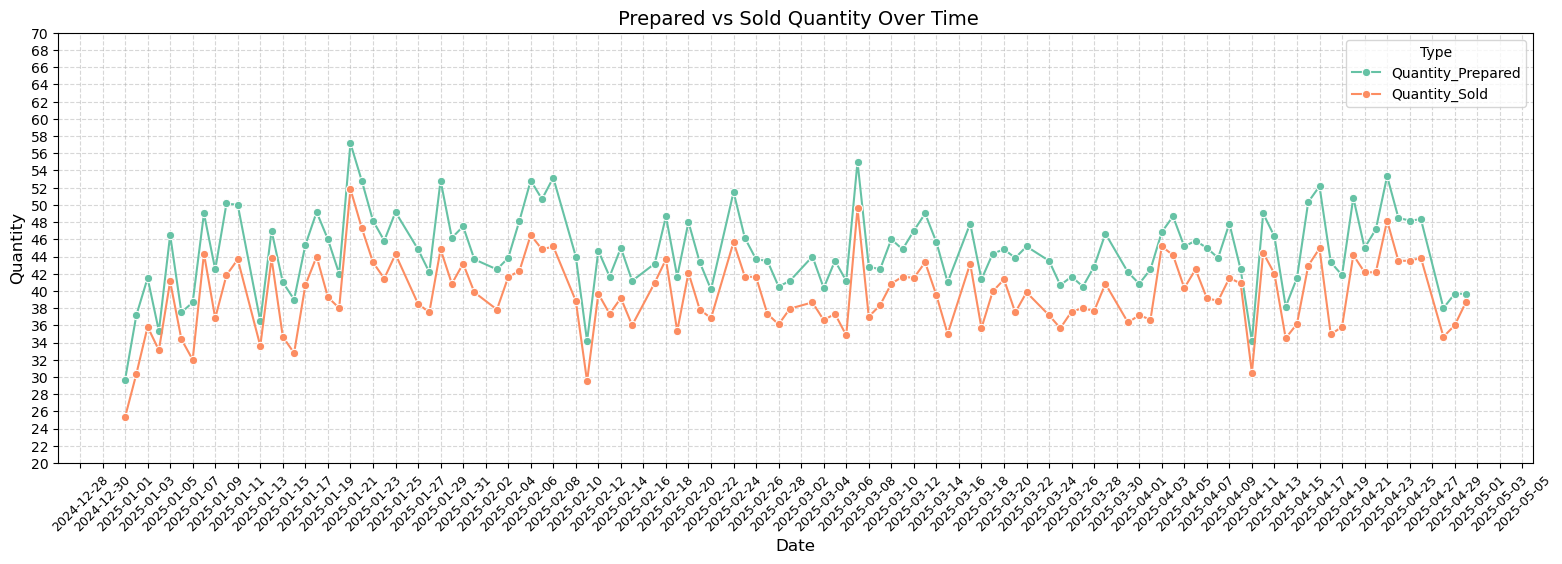

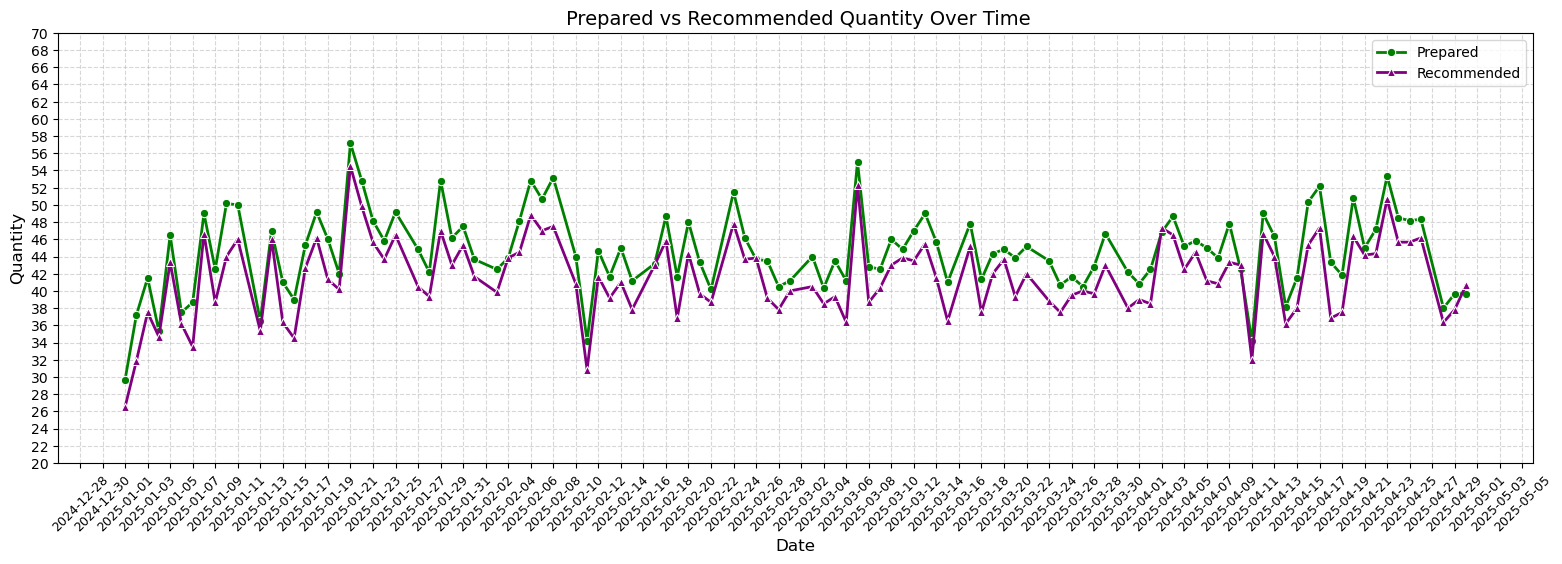

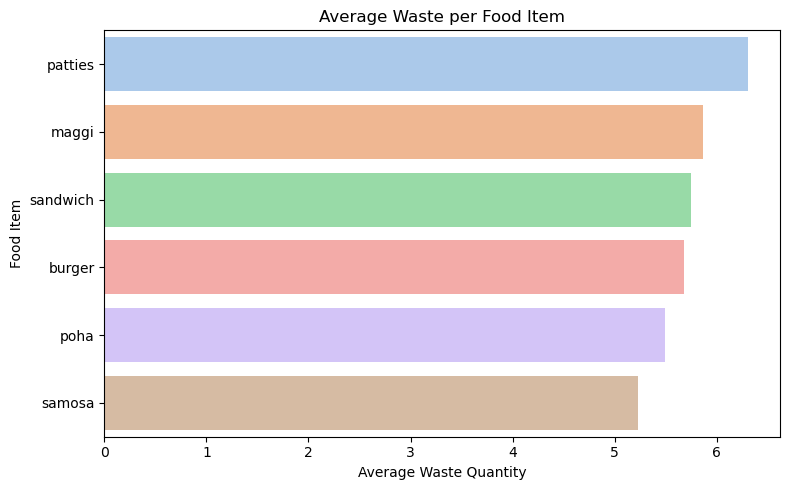

Plot 1 saved? True
Plot 2 saved? True
Plot 3 saved? True
file path exists? False
📁 Data saved successfully to: D:\Downloads\AI Project\Final Outputs\recommendations.csv


In [42]:
# PHASE - 1
# 0️⃣ Import required libraries
import os
import glob
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# load the cleaned dataset saved in phase-0
df = pd.read_csv(r"D:\Downloads\AI Project\Datasets\cleaned_data.csv")

# 3️⃣ Model Building – Linear Regression

# Save original for preview later
df['Original_Item'] = df['Item Name']

# One-hot encode 'Item Name'
df = pd.get_dummies(df, columns=['Item Name'], prefix='Item')

# Define features and target
item_cols = [col for col in df.columns if col.startswith('Item')]
X = df[['Quantity_Prepared', 'Day_encoded'] + item_cols]
y = df['Quantity_Sold']

# Train-Test split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LinearRegression()
model.fit(X_train, y_train)
print("model training complete")

# Define your full path (adjust if needed)
save_path = os.path.expanduser(r"D:\Downloads\AI Project\Trained model and Notebook")

# Ensure the folder exists
os.makedirs(save_path, exist_ok=True)

# Save files into that folder
joblib.dump(model, os.path.join(save_path, "multi_file_trained_model.pkl"))
joblib.dump(item_cols, os.path.join(save_path, "item_columns.pkl"))
print("✅ Model and item columns saved to 'Downloads/ai project/Trained model and Notebook'")

# evaluation of the model 
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = mse**0.5
r2 = r2_score(y_test, y_pred)

print(f"📊 MSE: {mse:.2f}")
print(f"📈 RMSE: {rmse:.2f}")
print(f"✅ R² Score (Accuracy): {r2:.2%}")

# Recommendation logic

# Add buffer and recommend new quantity
buffer = 0.05 * df['Quantity_Sold']
df['Recommended_Qty'] = (df['Quantity_Sold'] + buffer).clip(lower=0).round()

# ✅ Final table preview (optional)
print("🍽️ Final Table Preview:")
print(df[['Date', 'Original_Item', 'Quantity_Prepared', 'Quantity_Sold', 
          'Quantity_Wasted', 'Recommended_Qty']].tail(10))

# visualisations

# 📁 Target folder for saving plots
target_folder = r"D:\Downloads\AI Project\Plots and Visualisations"
os.makedirs(target_folder, exist_ok=True)

#  1 - prepared vs sold 
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df_melted = df.melt(id_vars='Date', value_vars=['Quantity_Prepared', 'Quantity_Sold'],
                    var_name='Type', value_name='Quantity')

plt.figure(figsize=(16,6))
sns.lineplot(data=df_melted, x='Date', y='Quantity', hue='Type', marker='o', palette='Set2', errorbar=None)
plt.title(" Prepared vs Sold Quantity Over Time", fontsize=14)
plt.xlabel("Date",fontsize=12)
plt.ylabel("Quantity",fontsize=12)
plt.xticks(rotation=45, fontsize=9)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
y_min, y_max = df[['Quantity_Prepared', 'Recommended_Qty']].min().min(), df[['Quantity_Prepared', 'Recommended_Qty']].max().max()
plt.yticks(np.arange(int(y_min), int(y_max)+1, step=2), fontsize=10)
plt.tight_layout(pad=2)
plt.grid(True,linestyle='--',alpha=0.5)
plt.savefig(os.path.join(target_folder, "prep_vs_sold_p1.png"))
plt.show()

# 2 - prepared vs reccomended
plt.figure(figsize=(16, 6))
sns.lineplot(data=df, x='Date', y='Quantity_Prepared', label='Prepared', marker='o', linewidth=2, color='green', errorbar=None)
sns.lineplot(data=df, x='Date', y='Recommended_Qty', label='Recommended', marker='^', linewidth=2, color='purple', errorbar=None)
plt.title(" Prepared vs Recommended Quantity Over Time", fontsize=14)
plt.xlabel("Date",fontsize=12)
plt.ylabel("Quantity",fontsize=12)
plt.xticks(rotation=45, fontsize=9)
plt.gca().xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
y_min, y_max = df[['Quantity_Prepared', 'Recommended_Qty']].min().min(), df[['Quantity_Prepared', 'Recommended_Qty']].max().max()
plt.yticks(np.arange(int(y_min), int(y_max)+1, step=2), fontsize=10)
plt.legend()
plt.tight_layout(pad=2)
plt.grid(True,linestyle='--',alpha=0.5)
plt.savefig(os.path.join(target_folder, "prep_vs_recomm_p1.png"))
plt.show()

# 3 - avg waste per food item(bar plot)
item_avg_waste = df.groupby('Original_Item')['Quantity_Wasted'].mean().sort_values(ascending=False)
item_df = item_avg_waste.reset_index()
item_df.columns = ['Item Name', 'Average Waste']
item_df['Hue'] = item_df['Item Name']

plt.figure(figsize=(8, 5))
sns.barplot(
    data=item_df,
    x='Average Waste',
    y='Item Name',
    hue='Hue',
    palette='pastel',
    dodge=False,
    legend=False
)
plt.title("Average Waste per Food Item")
plt.xlabel("Average Waste Quantity")
plt.ylabel("Food Item")
plt.tight_layout()
plt.savefig(os.path.join(target_folder, "item_vs_avg_waste_p1.png"))
plt.show()

# ✅ Confirm Plot Save
print("Plot 1 saved?", os.path.exists(os.path.join(target_folder, "prep_vs_sold_p1.png")))
print("Plot 2 saved?", os.path.exists(os.path.join(target_folder, "prep_vs_recomm_p1.png")))
print("Plot 3 saved?", os.path.exists(os.path.join(target_folder, "item_vs_avg_waste_p1.png")))

# ✅ Save final DataFrame with all new columns to a separate CSV
df.to_csv(r"D:\Downloads\AI Project\Final Outputs\recommendations.csv", index=False)
print("file path exists?", os.path.exists("recommendations.csv"))
print("📁 Data saved successfully to:", r"D:\Downloads\AI Project\Final Outputs\recommendations.csv")


### 🔷 Phase 2: Predicting Sales from Prepared Quantity (AI-Based)

This phase uses **machine learning (Linear Regression)** to predict how many items will likely be sold — even before sales happen — based on previous trends of preparation, item type, and weekday.

#### 📌 Purpose:
Imagine you've just prepared food, but don't yet know how many will be sold. Based on past behavior, this phase helps **predict sales in advance**, so that **waste can be estimated and minimized** proactively.

#### 📥 Input:
A new dataset (uploaded by user) with the following columns only:
- `Date`
- `Item Name`
- `Quantity_Prepared`

#### ⚙️ Steps:
1. **Model Training**:
   - Uses Phase 1's cleaned dataset with known `Quantity_Sold`
   - Applies one-hot encoding to food items
   - Learns the relationship between `Quantity_Prepared`, `Day`, and the actual `Quantity_Sold`

2. **Prediction**:
   - The model predicts `Quantity_Sold` for the new dataset
   - Calculates **Estimated Waste** = `Quantity_Prepared - Predicted_Sold`
   - Applies a buffer and logic to give a final **Recommended Quantity** for minimal wastage

3. **Output**:
   - Saves final predictions and insights in `final_predictions_output_2.csv`
   - Generates comparison graphs:
     - Prepared vs Predicted Sold
     - Actual Sold (Phase 1) vs Predicted Sold (Phase 2)
     - Actual Waste vs Estimated Waste
     - Recommended Quantities: Phase 1 vs Phase 2

#### ✅ Outcome:
Canteen managers can now **simulate future scenarios** — if they prep X amount, how much is likely to be sold? This helps in **planning better** without waiting for actual sales data.

> ⚠️ Note: This phase depends on Phase 1's training. So always run Phase 1 first! i.e don't break the order always go - Phase-0 then Phase-1 and finally Phase-2.


🔁 Phase-2 Run ID: P2_Run_2025-12-31_10-39-42
✅ Model and item columns loaded
✅ New data loaded
✅ Preprocessing complete
✅ Predictions generated
✅ CSV outputs saved


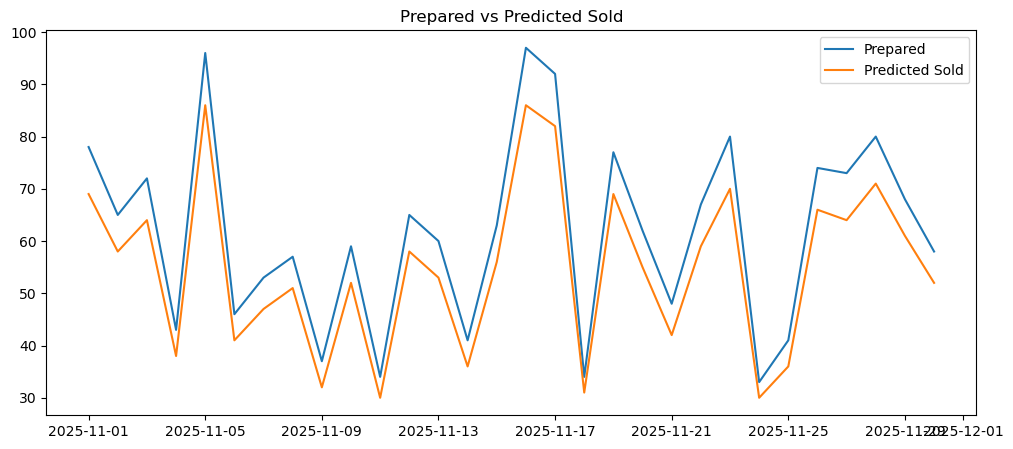

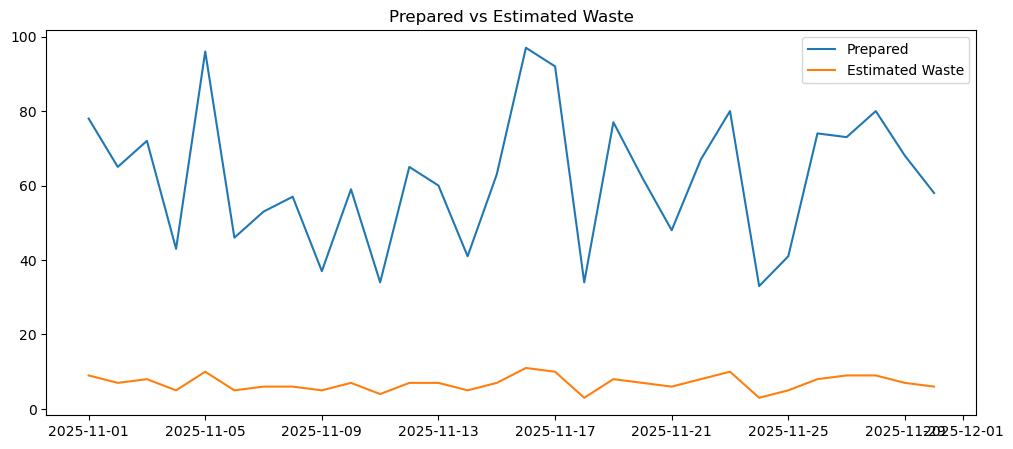

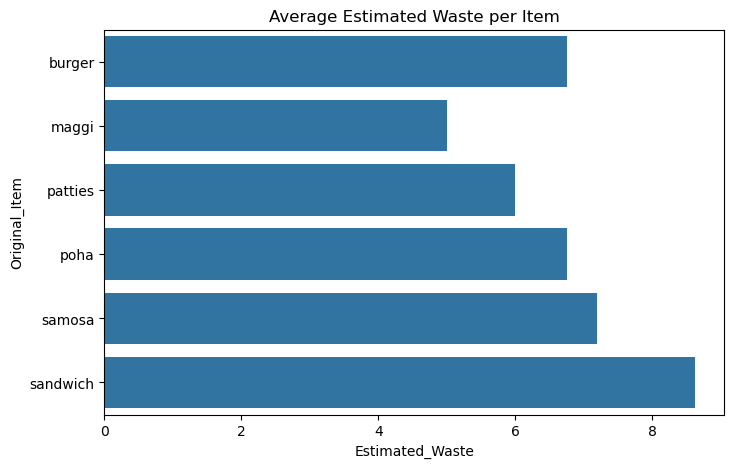

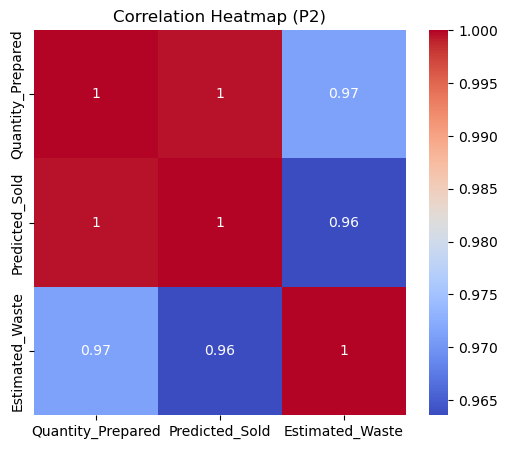

✅ All plots saved
🎉 Phase-2 completed successfully
📁 Outputs: D:\Downloads\AI Project\Final Outputs\P2_Run_2025-12-31_10-39-42
📊 Plots: D:\Downloads\AI Project\Plots and Visualisations\P2_Run_2025-12-31_10-39-42


In [43]:
# =========================
# PHASE – 2 : PREDICTION & ESTIMATED WASTE
# =========================

# 🔹 Imports
import joblib
import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from rapidfuzz import process

# =========================
# 🔹 RUN ID (VERY IMPORTANT)
# =========================
run_id = datetime.now().strftime("P2_Run_%Y-%m-%d_%H-%M-%S")
print("🔁 Phase-2 Run ID:", run_id)

# =========================
# 🔹 LOAD TRAINED MODEL
# =========================
MODEL_PATH = r"D:\Downloads\AI Project\Trained model and Notebook"
sold_model = joblib.load(os.path.join(MODEL_PATH, "multi_file_trained_model.pkl"))
item_cols = joblib.load(os.path.join(MODEL_PATH, "item_columns.pkl"))
print("✅ Model and item columns loaded")

# =========================
# 🔹 LOAD NEW DATA
# =========================
from tkinter import Tk
from tkinter.filedialog import askopenfilename

Tk().withdraw()
file_path = askopenfilename(
    title="Select new canteen data file",
    filetypes=[("CSV files", "*.csv"), ("Excel files", "*.xlsx")]
)

df = pd.read_csv(file_path) if file_path.endswith(".csv") else pd.read_excel(file_path)

required_cols = {'Date', 'Item Name', 'Quantity_Prepared'}
if not required_cols.issubset(df.columns):
    raise ValueError("❌ Required columns missing")

print("✅ New data loaded")

# =========================
# 🔹 PREPROCESSING
# =========================
df = df.copy()

# Load menu
menu = pd.read_csv(r"D:\Downloads\AI Project\Datasets\menu.csv")
menu['Item Name'] = menu['Item Name'].str.lower().str.strip()
menu_items = menu['Item Name'].unique().tolist()

# Manual spelling fixes
corrections = {
    "brgr": "burger", "burgar": "burger",
    "maggie": "maggi", "maggi": "maggi",
    "patis": "patties", "pattis": "patties",
    "pohaa": "poha", "poh": "poha",
    "samsa": "samosa", "smosa": "samosa",
    "sandwch": "sandwich", "sandwih": "sandwich"
}

def fix_name(x):
    x = str(x).lower().strip()
    return corrections.get(x, x)

def fuzzy_match(x):
    match = process.extractOne(x, menu_items)
    return match[0] if match and match[1] >= 85 else x

df['Item Name'] = df['Item Name'].apply(fix_name).apply(fuzzy_match)

# Date + numeric cleaning
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Quantity_Prepared'] = pd.to_numeric(df['Quantity_Prepared'], errors='coerce').round().astype(int)
df = df[df['Quantity_Prepared'] >= 0]

df['Day_encoded'] = df['Date'].dt.dayofweek

print("✅ Preprocessing complete")

# =========================
# 🔹 FEATURE ALIGNMENT
# =========================
df['Original_Item'] = df['Item Name']
df = pd.get_dummies(df, columns=['Item Name'], prefix='Item')

for col in item_cols:
    if col not in df.columns:
        df[col] = 0

X = df[['Quantity_Prepared', 'Day_encoded'] + item_cols]

# =========================
# 🔹 PREDICTIONS
# =========================
df['Predicted_Sold'] = np.clip(sold_model.predict(X).round(), 0, None)
df['Estimated_Waste'] = (df['Quantity_Prepared'] - df['Predicted_Sold']).clip(lower=0)

buffer = 0.05 * df['Predicted_Sold']
df['Recommended_Qty'] = (df['Predicted_Sold'] + buffer).round()

print("✅ Predictions generated")

# =========================
# 🔹 RUN-WISE OUTPUT FOLDERS
# =========================
BASE_OUTPUT = r"D:\Downloads\AI Project\Final Outputs"
BASE_PLOTS = r"D:\Downloads\AI Project\Plots and Visualisations"

FINAL_DIR = os.path.join(BASE_OUTPUT, run_id)
PLOT_DIR = os.path.join(BASE_PLOTS, run_id)

os.makedirs(FINAL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

# =========================
# 🔹 SAVE CSV OUTPUTS
# =========================
df.to_csv(os.path.join(FINAL_DIR, "phase2_predictions_output.csv"), index=False)

item_waste = df.groupby('Original_Item')['Estimated_Waste'].mean().reset_index()
item_waste.to_csv(os.path.join(FINAL_DIR, "Itemwise_Estimated_Waste_p2.csv"), index=False)

day_summary = df.groupby('Date')[['Quantity_Prepared','Predicted_Sold','Estimated_Waste','Recommended_Qty']].mean().reset_index()
day_summary.to_csv(os.path.join(FINAL_DIR, "Daywise_Averages_p2.csv"), index=False)

print("✅ CSV outputs saved")

# =========================
# 🔹 VISUALISATIONS
# =========================
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Quantity_Prepared'], label='Prepared')
plt.plot(df['Date'], df['Predicted_Sold'], label='Predicted Sold')
plt.legend()
plt.title("Prepared vs Predicted Sold")
plt.savefig(os.path.join(PLOT_DIR, "prep_vs_pred_p2.png"))
plt.show()

plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Quantity_Prepared'], label='Prepared')
plt.plot(df['Date'], df['Estimated_Waste'], label='Estimated Waste')
plt.legend()
plt.title("Prepared vs Estimated Waste")
plt.savefig(os.path.join(PLOT_DIR, "prep_vs_estim_waste_p2.png"))
plt.show()

plt.figure(figsize=(8,5))
sns.barplot(data=item_waste, x='Estimated_Waste', y='Original_Item')
plt.title("Average Estimated Waste per Item")
plt.savefig(os.path.join(PLOT_DIR, "itemwise_estim_waste_p2.png"))
plt.show()

plt.figure(figsize=(6,5))
sns.heatmap(df[['Quantity_Prepared','Predicted_Sold','Estimated_Waste']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap (P2)")
plt.savefig(os.path.join(PLOT_DIR, "correlation_heatmap_p2.png"))
plt.show()

print("✅ All plots saved")

# =========================
# 🔹 FINAL CONFIRMATION
# =========================
print("🎉 Phase-2 completed successfully")
print("📁 Outputs:", FINAL_DIR)
print("📊 Plots:", PLOT_DIR)


---

# ✅ Conclusion

This project proves how data and machine learning can drive smarter food decisions in school canteens.  
From uncovering patterns in daily consumption to predicting future needs, our system helps minimize waste and ensures food is prepared in just the right amounts — **efficiently, responsibly, and intelligently**.

With every prediction, we're one step closer to more thoughtful resource use and less unnecessary waste.

---

### 🔮 What’s Next?

To scale and enhance this project further, we envision:

- 📱 **Build a user-friendly app** for staff to upload records and receive instant AI-based suggestions.
- 📊 **Upgrade to advanced ML models** like Random Forests or Time Series Forecasting for better precision.
- 📡 **Integrate IoT sensors** (smart scales, bin trackers) to automate real-time data collection.
- 🤝 **Enable food donations** based on predicted surplus by linking with local NGOs and food banks.

---

> This isn’t just code — it’s a commitment to smarter kitchens and a less wasteful world. 🌍

---
